# Vorlage Plausi-Tests

### Wegzüge nach auswärts nach Wegzugsort, Stadtquartier, Geschlecht, Altersgruppe und Zivilstand, seit 1993

Anzahl Wegzüge von Personen aus der Stadt Zürich nach Wegzugsort, Stadtkreis, Statistischem Stadtquartier, Geschlecht, Altersgruppe, Zivilstand und Jahr, seit 1993.

Die Wegzugsorte sind auf Bezirks- und Kantonensebene aggregiert, in welche die Personen in der Schweiz weggezogen sind. Wenn sie ins Ausland weggezogen sind, so ist eine Aggregierung nach Region und Kontinent möglich.


Datum: 30.08.2023

**Dataset auf INTEG Datenkatalog**:  https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_wegz_jahr_quartier_ag_zivilstand_od3522

**Dataset auf PROD Datenkatalog**:  https://data.stadt-zuerich.ch/dataset/bev_wegz_jahr_quartier_ag_zivilstand_od3522

### Importiere die notwendigen Packages

In [32]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly

In [33]:
import pandas as pd
import pivottablejs
from pivottablejs import pivot_ui
import numpy as np
import altair as alt
import datetime
import geopandas as gpd
import folium 
import plotly.express as px
import seaborn as sns
import requests
import io

import matplotlib.pyplot as plt
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)


In [34]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [35]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [36]:
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

### Zeitvariabeln
Bestimme den aktuellst geladenen Monat. Hier ist es der Stand vor 2 Monaten. 
Bestimme noch weitere evt. sinnvolle Zeitvariabeln.

Zum Unterschied zwischen import datetime und from datedtime import datetime, siehe https://stackoverflow.com/questions/15707532/import-datetime-v-s-from-datetime-import-datetime

Zuerst die Zeitvariabeln als Strings

In [37]:
now = datetime.date.today()
date_today = now.strftime("%Y-%m-%d")
year_today = now.strftime("%Y")
month_today = now.strftime("%m")
day_today = now.strftime("%d")

date_day_a_week_ago = (datetime.datetime.now() - datetime.timedelta(days=7)).date()
day_a_week_ago = date_day_a_week_ago.strftime('%Y-%m-%d')


print(now," vor einer Woche: ", day_a_week_ago)


2024-03-13  vor einer Woche:  2024-03-06


#### Und hier noch die Zeitvariabeln als Integers:
- `aktuellesJahr`
- `aktuellerMonat`: Der gerade jetzt aktuelle Monat
- `selectedMonat`: Der aktuellste Monat in den Daten. In der Regel zwei Monate her.

In [38]:
#now = datetime.now() 
int_times = now.timetuple()

aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2

print(aktuellesJahr, 
      aktuellerMonat,
    'datenstand: ', selectedMonat,
     int_times)



2024 3 datenstand:  1 time.struct_time(tm_year=2024, tm_mon=3, tm_mday=13, tm_hour=0, tm_min=0, tm_sec=0, tm_wday=2, tm_yday=73, tm_isdst=-1)


### Setze einige Pfadvariabeln

- Der Packagename ist eigentlich der **Verzeichnisname** unter dem die Daten und Metadaten auf der Dropzone abgelegt werden.
- Definiert wird er bei SASA-Prozessen auf dem **Produkte-Sharepoint ([Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/PersonalViews.aspx?PageView=Personal&ShowWebPart={6087A3E7-8AC8-40BA-8278-DECFACE124FF}))**.
- Der Packagename wird auf CKAN teil der URL, daher ist die exakte Schreibweise wichtig.

Beachte: im Packagename müssen alle Buchstaben **klein** geschrieben werden. Dies weil CKAN aus grossen kleine Buchstaben macht.

##### `HIER ANPASSEN`

In [39]:
package_name = "bev_wegz_jahr_quartier_ag_zivilstand_od3522"
dataset_name = "BEV352OD3522.csv"

**Statische Pfade in DWH-Dropzones und CKAN-URLs**

In [40]:
dropzone_path_integ = r"\\szh\ssz\applikationen\OGD_Dropzone\INT_DWH"
dropzone_path_prod = r"\\szh\ssz\applikationen\OGD_Dropzone\DWH"
ckan_integ_url ="https://data.integ.stadt-zuerich.ch/dataset/int_dwh_"
ckan_prod_url ="https://data.stadt-zuerich.ch/dataset/"

### Checke die Metadaten auf der CKAN INTEG- oder PROD-Webseite

Offenbar lassen sich aktuell im Markdownteil keine Variabeln ausführen, daher gehen wir wie unten gezeigt vor. Siehe dazu: https://data-dive.com/jupyterlab-markdown-cells-include-variables
Instead of setting the cell to Markdown, create Markdown from withnin a code cell! We can just use python variable replacement syntax to make the text dynamic

In [41]:
from IPython.display import Markdown as md

In [42]:
md(" **1. Dataset auf INTEG-Datakatalog:** Link {} ".format(ckan_integ_url+package_name))

 **1. Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_wegz_jahr_quartier_ag_zivilstand_od3522 

In [43]:
md(" **2. Dataset auf PROD-Datakatalog:** Link {} ".format(ckan_prod_url+package_name))

 **2. Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_wegz_jahr_quartier_ag_zivilstand_od3522 

### Importiere einen Datensatz 

Definiere zuerst folgende Werte:
1) Kommt der Datensatz von PROD oder INTEG?
2) Beziehst Du den Datensatz direkt ab der DROPZONE oder aus dem INTERNET?

In [44]:
#Die Datasets sind nur zum Testen auf INT-DWH-Dropzone. Wenn der Test vorbei ist, sind sie auf PROD. 
# Über den Status kann man einfach switchen

status = "int"; #prod vs something else
data_source = "web"; #dropzone vs something else
print(status+" - "+ data_source)

int - web


In [45]:
# Filepath
if status == "prod":
    if data_source == "dropzone":
            fp = dropzone_path_prod+"\\"+ package_name +"\\"+dataset_name
            print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_prod_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)
else:
    if data_source == "dropzone":
        fp = dropzone_path_integ+"\\"+ package_name +"\\"+dataset_name
        print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_integ_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)


fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_wegz_jahr_quartier_ag_zivilstand_od3522/download/BEV352OD3522.csv


In [46]:
# Read the data
if data_source == "dropzone":
    data2betested = pd.read_csv(
        fp
        , sep=','
        ,parse_dates=['StichtagDatJahr']
        ,low_memory=False
    )
    print("dropzone")
else:
    r = requests.get(fp, verify=False)  
    r.encoding = 'utf-8'
    data2betested = pd.read_csv(
        io.StringIO(r.text)
        ,parse_dates=['StichtagDatJahr']
        # KONVERTIERE DAS SAS DATUM IN EIN UNIXDATUM UND FORMATIERE ES
        #, date_parser=lambda s: epoch + datetime.timedelta(days=int(s))
        ,low_memory=False)
    print("web")

data2betested.dtypes

web


StichtagDatJahr      datetime64[ns]
WegBezirkHistSort             int64
WegBezirkHistLang            object
WegKtHistSort                 int64
WegKtHistLang                object
WegLandHistSort               int64
WegLandHistLang              object
WegRegionSort                 int64
WegRegionLang                object
WegKontinentSort              int64
WegKontinentLang             object
QuarSort                      int64
QuarLang                     object
KreisSort                     int64
AlterV10Sort                  int64
AlterV10Kurz                 object
SexKurz                      object
Ziv2Sort                      int64
Ziv2Lang                     object
AnzWezuWir                    int64
dtype: object

Berechne weitere Attribute falls notwendig

In [47]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_str = lambda x: x.StichtagDatJahr.astype(str),
        
    )
    .sort_values('Jahr', ascending=False)
    )
#data2betested.dtypes

### Einfache Datentests

In [48]:
data2betested.sort_values("AnzWezuWir",ascending=True).head(2).T

,309502,184929
StichtagDatJahr,2009-01-01 00:00:00,2002-01-01 00:00:00
WegBezirkHistSort,900,9999
WegBezirkHistLang,Kanton Zug,Ausland
WegKtHistSort,9,99
WegKtHistLang,Zug,Ausland
WegLandHistSort,8100,8227
WegLandHistLang,Schweiz,Niederlande
WegRegionSort,13,14
WegRegionLang,Zentraleuropa,Westeuropa
WegKontinentSort,1,1


In [49]:
#data2betested.dtypes
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 578472 entries, 578471 to 0
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   StichtagDatJahr    578472 non-null  datetime64[ns]
 1   WegBezirkHistSort  578472 non-null  int64         
 2   WegBezirkHistLang  578472 non-null  object        
 3   WegKtHistSort      578472 non-null  int64         
 4   WegKtHistLang      578472 non-null  object        
 5   WegLandHistSort    578472 non-null  int64         
 6   WegLandHistLang    578472 non-null  object        
 7   WegRegionSort      578472 non-null  int64         
 8   WegRegionLang      578472 non-null  object        
 9   WegKontinentSort   578472 non-null  int64         
 10  WegKontinentLang   578472 non-null  object        
 11  QuarSort           578472 non-null  int64         
 12  QuarLang           578472 non-null  object        
 13  KreisSort          578472 non-null  int64   

In [50]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 578,472 rows (observations) and 22 columns (variables).
There seem to be 0 exact duplicates in the data.


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [51]:
data2betested = data2betested.set_index("Jahr")
data2betested = data2betested.sort_index()
#data2betested = data2betested.reset_index()

In [52]:
data2betested.index.year.unique()

Int64Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
            2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
            2021, 2022, 2023],
           dtype='int64', name='Jahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [53]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

,StichtagDatJahr,WegBezirkHistLang,WegKtHistLang,WegLandHistLang,WegRegionLang,WegKontinentLang,QuarLang,AlterV10Kurz,SexKurz,Ziv2Lang,Jahr_str
count,578472,578472,578472,578472,578472,578472,578472,578472,578472,578472,578472
unique,NaN,236,29,225,31,6,34,11,2,7,31
top,NaN,Ausland,Ausland,Schweiz,Zentraleuropa,Europa,Altstetten,20-29,M,Ledig,1997-01-01
freq,NaN,196905,196905,351838,383740,470170,31639,162441,295289,318745,19528
mean,2007-11-14 14:46:42.721653248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1993-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2000-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2008-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2023-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Beschreibe numerische Attribute

In [54]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,WegBezirkHistSort,WegKtHistSort,WegLandHistSort,WegRegionSort,WegKontinentSort,QuarSort,KreisSort,AlterV10Sort,Ziv2Sort,AnzWezuWir
count,"578,472","578,472","578,472","578,472","578,472","578,472","578,472","578,472","578,472","578,472"
mean,"4,412",44,"8,239",21,2,72,7,4,2,2
std,"4,439",44,287,19,2,34,3,2,1,4
min,101,1,"8,100",11,1,11,1,1,1,0
25%,111,1,"8,100",13,1,42,4,3,1,1
50%,"1,903",19,"8,100",13,1,72,7,4,1,1
75%,"9,999",99,"8,236",15,1,102,10,5,2,2
max,"9,999",99,"9,999",88,8,123,12,11,9,601


#### Nullwerte und Missings?

Wie viele Nullwerte gibt es im Datensatz?

In [55]:
data2betested.isnull().sum()

StichtagDatJahr      0
WegBezirkHistSort    0
WegBezirkHistLang    0
WegKtHistSort        0
WegKtHistLang        0
WegLandHistSort      0
WegLandHistLang      0
WegRegionSort        0
WegRegionLang        0
WegKontinentSort     0
WegKontinentLang     0
QuarSort             0
QuarLang             0
KreisSort            0
AlterV10Sort         0
AlterV10Kurz         0
SexKurz              0
Ziv2Sort             0
Ziv2Lang             0
AnzWezuWir           0
Jahr_str             0
dtype: int64

### Gibt es Duplikate?

In [56]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,StichtagDatJahr,WegBezirkHistSort,WegBezirkHistLang,WegKtHistSort,WegKtHistLang,WegLandHistSort,WegLandHistLang,...,AlterV10Sort,AlterV10Kurz,SexKurz,Ziv2Sort,Ziv2Lang,AnzWezuWir,Jahr_str
Jahr,,,,,,,,,,,,,,,


In [57]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

Zeige ein Histogramm für jedes numerische Attribut

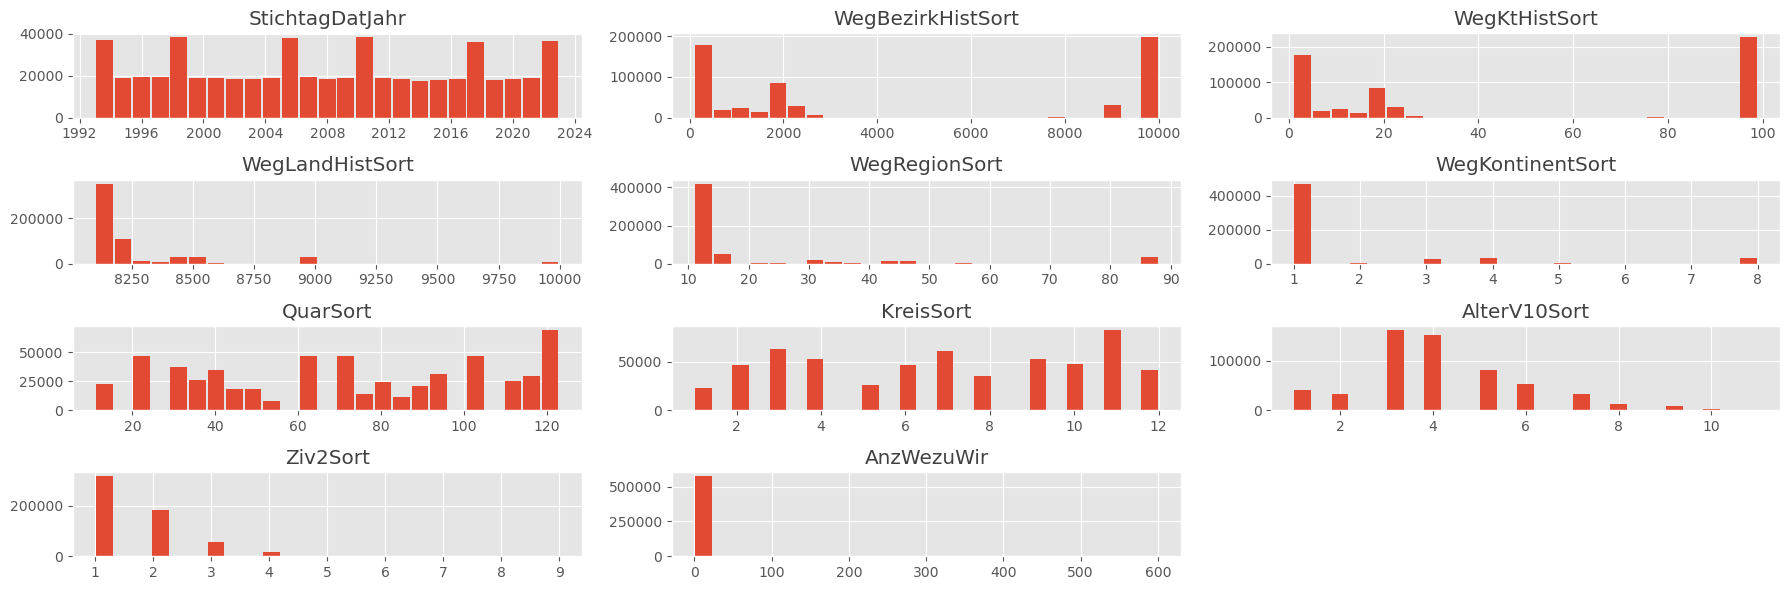

In [58]:
# plot a histogram for each numerical feature
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gruppierungen

In [59]:
agg_jahr = data2betested.loc["1992":year_today]\
    .groupby(['Jahr_str']) \
    .agg(sum_AnzWezuWir=('AnzWezuWir', 'sum')) \
    .sort_values('Jahr_str', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr_str,sum_AnzWezuWir
0,2023-01-01,38985
1,2022-01-01,39302
2,2021-01-01,39719


In [60]:
data2betested.columns

Index(['StichtagDatJahr', 'WegBezirkHistSort', 'WegBezirkHistLang', 'WegKtHistSort',
       'WegKtHistLang', 'WegLandHistSort', 'WegLandHistLang', 'WegRegionSort', 'WegRegionLang',
       'WegKontinentSort', 'WegKontinentLang', 'QuarSort', 'QuarLang', 'KreisSort', 'AlterV10Sort',
       'AlterV10Kurz', 'SexKurz', 'Ziv2Sort', 'Ziv2Lang', 'AnzWezuWir', 'Jahr_str'],
      dtype='object')

In [61]:
agg_KT = data2betested.loc["1930":year_today]\
    .groupby(['Jahr_str', 'WegBezirkHistLang','WegKtHistSort','WegKtHistLang']) \
    .agg(sum_AnzWezuWir=('AnzWezuWir', 'sum')) \
    .sort_values(['Jahr_str','WegKtHistSort'], ascending=[False, False]) 
agg_KT.reset_index().head(4)

,Jahr_str,WegBezirkHistLang,WegKtHistSort,WegKtHistLang,sum_AnzWezuWir
0,2023-01-01,Ausland,99,Ausland,10574
1,2023-01-01,Unbekannt,98,Unbekannt,4572
2,2023-01-01,Schweiz Unbekannt,79,Schweiz Unbekannt,1
3,2023-01-01,District de Delémont,26,Jura,6


In [62]:
agg_NationHist = data2betested.loc["1930":year_today]\
    .groupby(['NationHistSort', 'NationHistLang','NationSort', 'NationLang', ]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('NationHistSort', ascending=False) 
agg_NationHist.reset_index().head(5)

KeyError: 'NationHistSort'

In [63]:
agg_Region= data2betested.loc["1930":year_today]\
    .groupby(['RegionSort', 'RegionLang',]) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('RegionSort', ascending=False) 
agg_Region.reset_index().head(5)

KeyError: 'RegionSort'

In [ ]:
data2betested.columns

Index(['StichtagDatJahr', 'QuarSort', 'QuarCd', 'QuarLang', 'NationHistSort', 'NationHistLang',
       'NationSort', 'NationLang', 'RegionSort', 'RegionLang', 'KontinentSort', 'KontinentLang',
       'AnzBestWir', 'Jahr_str'],
      dtype='object')

In [ ]:
agg_Kontinent= data2betested.loc["1930":year_today]\
    .groupby(['KontinentSort', 'KontinentLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('KontinentSort', ascending=False) 
agg_Kontinent.reset_index().head(8)

,KontinentSort,KontinentLang,sum_AnzBestWir
0,8,Unzuteilbar,3042
1,5,Ozeanien,9980
2,4,Asien,352438
3,3,Amerika,180150
4,2,Afrika,141646
5,1,Europa,10926677


### Einfache Visualisierungen zur Plausi

Exploriere die Daten mit Pivottable.JS

In [ ]:
from pivottablejs import pivot_ui

#pivot_ui(data2betested)

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [ ]:
data2betested.loc["2022"].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,StichtagDatJahr,QuarSort,QuarCd,QuarLang,NationHistSort,NationHistLang,NationSort,NationLang,RegionSort,RegionLang,KontinentSort,KontinentLang,AnzBestWir,Jahr_str
Jahr,,,,,,,,,,,,,,
2022-01-01,2022-01-01,11,11,Rathaus,8223,Luxemburg,8223,Luxemburg,14,Westeuropa,1,Europa,3,2022-01-01
2022-01-01,2022-01-01,11,11,Rathaus,8211,Finnland,8211,Finnland,11,Nordeuropa,1,Europa,9,2022-01-01


### Visualisierungen nach Zeitausschnitten

#### Entwicklung der Wohnbevölkerung nach Staatsangehörigkeit, seit 1993

In [ ]:
data2betested.columns

Index(['StichtagDatJahr', 'QuarSort', 'QuarCd', 'QuarLang', 'NationHistSort', 'NationHistLang',
       'NationSort', 'NationLang', 'RegionSort', 'RegionLang', 'KontinentSort', 'KontinentLang',
       'AnzBestWir', 'Jahr_str'],
      dtype='object')

In [ ]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAggBar = data2betested.loc["1992":year_today]\
    .groupby(['Jahr', 'KontinentSort', 'KontinentLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('KontinentSort', ascending=True) 

myAggBar.reset_index().head(2)
#myAgg.reset_index().melt()

,Jahr,KontinentSort,KontinentLang,sum_AnzBestWir
0,1993-01-01,1,Europa,346902
1,1998-01-01,1,Europa,340844


In [ ]:
myTitle="Entwicklung der Wohnbevölkerung nach dem Kontinent der Staatsangehörigkeit (ohne Europa)"

highlight = alt.selection(type='single', on='mouseover',
                          fields=['KontinentLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAggBar.reset_index().query('KontinentSort > 1'), title=myTitle).encode(
    x=alt.X('Jahr', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_AnzBestWir', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('KontinentLang', legend=alt.Legend(title="Kontinent", orient="right"))  
    ,tooltip=['Jahr', 'KontinentLang','sum_AnzBestWir']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=750 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(1.2), alt.value(4))
).interactive()

lines + points

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [ ]:
myAggBar = data2betested.loc["2022"]\
    .groupby(['Jahr', 'RegionSort', 'RegionLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('sum_AnzBestWir', ascending=True) 

myAggBar.reset_index().dtypes


Jahr              datetime64[ns]
RegionSort                 int64
RegionLang                object
sum_AnzBestWir             int64
dtype: object

In [ ]:
#help(sns.catplot)  
#Stile for the following sns graphs
sns.set_theme(style="whitegrid")   

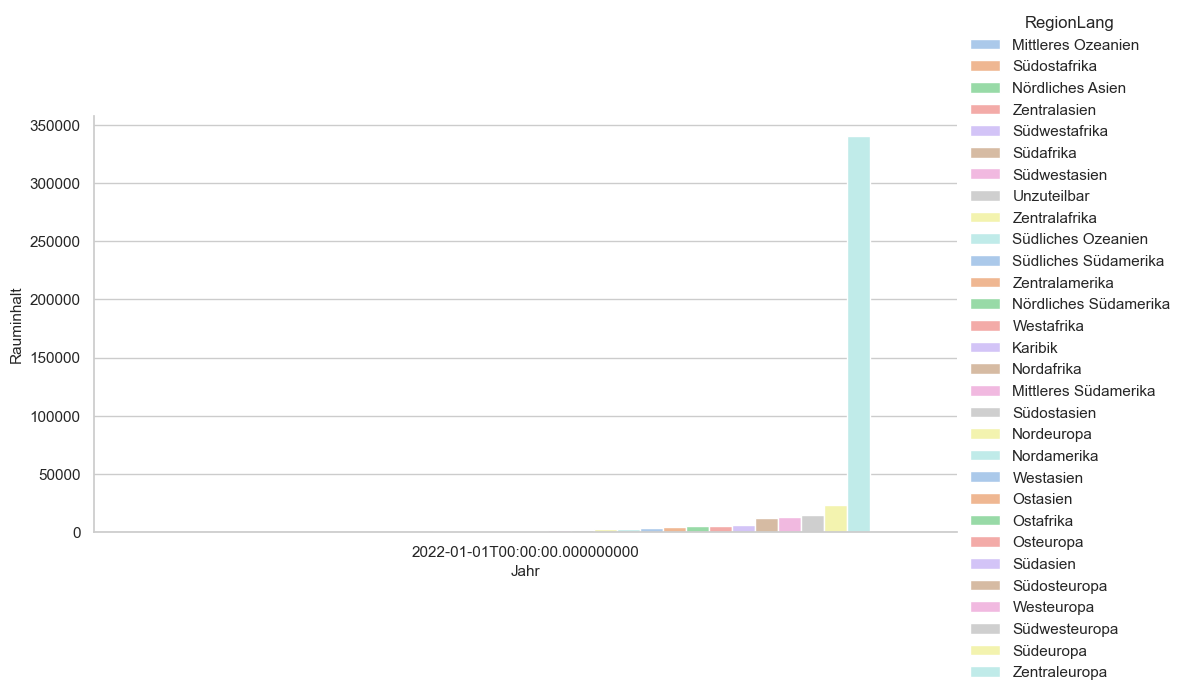

In [ ]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="Jahr"
            , y="sum_AnzBestWir"
            , hue="RegionLang"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBar.query("RegionSort >0").reset_index()
           )
myHist.set_xlabels('Jahr', fontsize=11) # not set_label
myHist.set_ylabels('Rauminhalt', fontsize=11)


In [ ]:
data2betested.columns

Index(['StichtagDatJahr', 'QuarSort', 'QuarCd', 'QuarLang', 'NationHistSort', 'NationHistLang',
       'NationSort', 'NationLang', 'RegionSort', 'RegionLang', 'KontinentSort', 'KontinentLang',
       'AnzBestWir', 'Jahr_str'],
      dtype='object')

##### Facet Grids: Entwicklung der Bevölkerung nach Staatsangehörigkeit und Quartier, seit 1993

In [ ]:
myAggFG1 = data2betested.loc["1993":year_today]\
    .groupby(['Jahr', 'NationSort', 'NationLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('NationSort', ascending=True) 

myAggFG1.reset_index().head(2)

,Jahr,NationSort,NationLang,sum_AnzBestWir
0,1993-01-01,8100,Schweiz,264041
1,2003-01-01,8100,Schweiz,255649


In [ ]:
myAggFG2 = data2betested.loc["1993":year_today]\
    .groupby(['Jahr', 'QuarSort', 'QuarCd', 'QuarLang', 'NationSort', 'NationLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('QuarSort', ascending=True) 

myAggFG2.reset_index().head(2)

,Jahr,QuarSort,QuarCd,QuarLang,NationSort,NationLang,sum_AnzBestWir
0,1993-01-01,11,11,Rathaus,8100,Schweiz,2487
1,2020-01-01,11,11,Rathaus,8315,Guinea,1


In [ ]:
myAggFG3 = data2betested.loc["1993":year_today]\
    .groupby(['Jahr', 'QuarSort', 'QuarCd', 'QuarLang', 'KontinentSort', 'KontinentLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('QuarSort', ascending=True) 

myAggFG3.reset_index().head(2)

,Jahr,QuarSort,QuarCd,QuarLang,KontinentSort,KontinentLang,sum_AnzBestWir
0,1993-01-01,11,11,Rathaus,1,Europa,2964
1,2008-01-01,11,11,Rathaus,1,Europa,2870


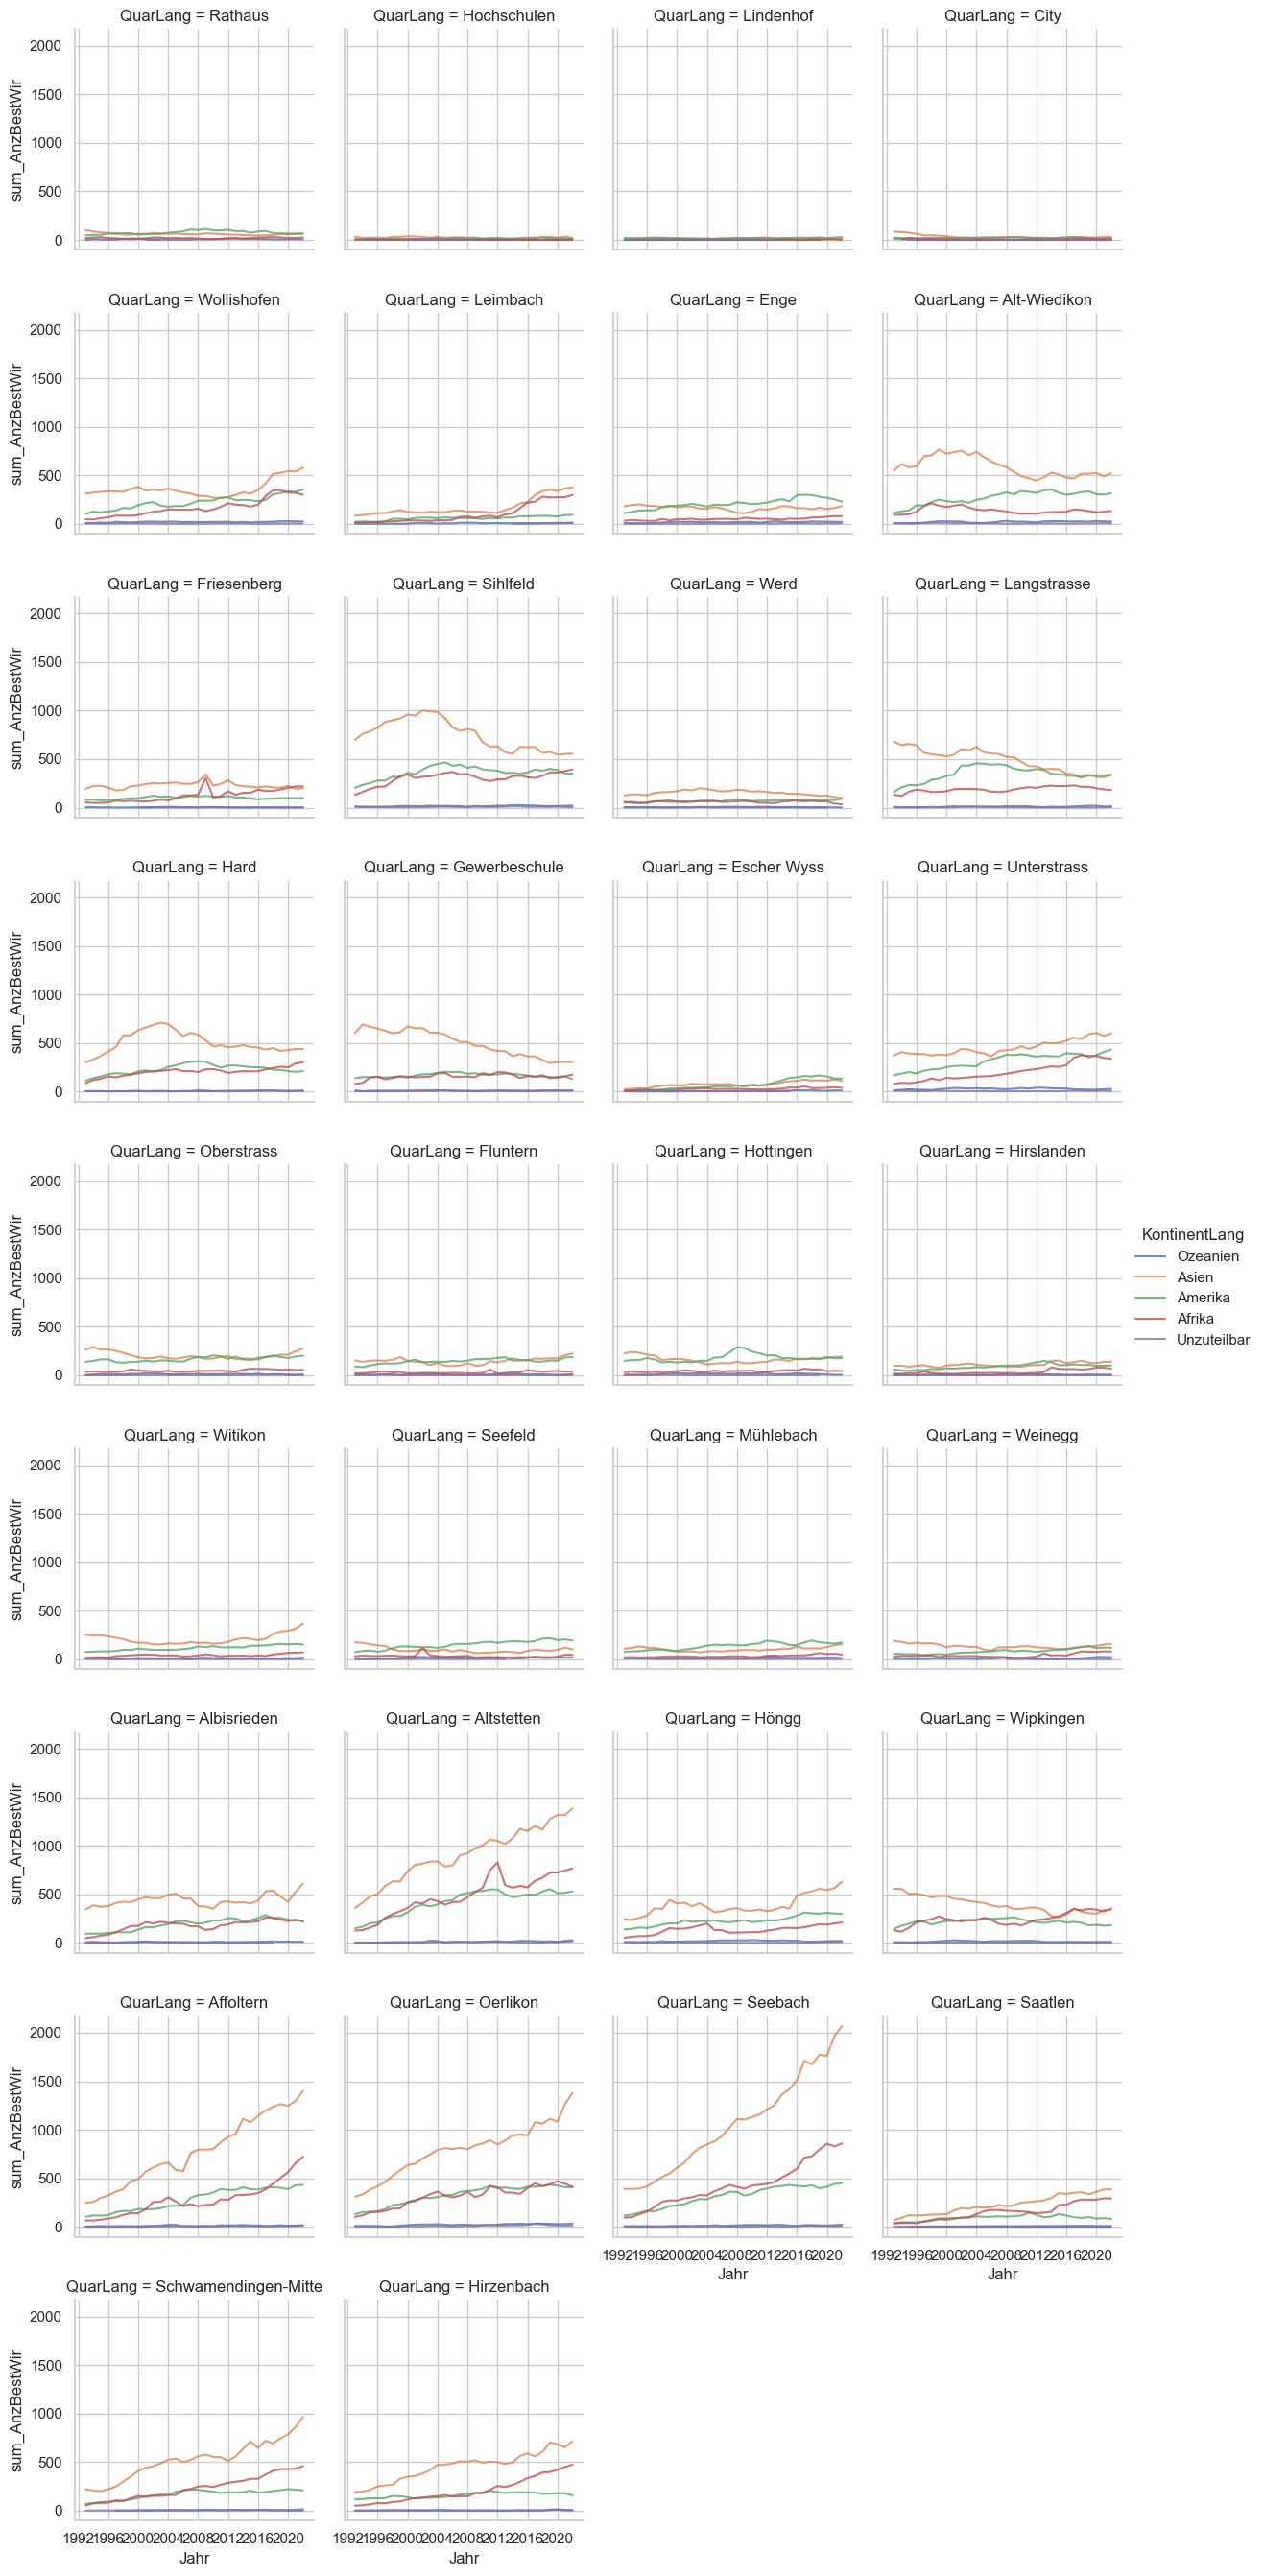

In [ ]:

g2 = sns.FacetGrid(myAggFG3.query('KontinentSort>1').reset_index(), col="QuarLang", hue="KontinentLang", col_wrap=4, height=3,)
g2.map(sns.lineplot, "Jahr","sum_AnzBestWir", alpha=.8)
g2.add_legend()


In [ ]:
#Dauert lange, daher aktuell ausgeklammert
# #g3 = sns.FacetGrid(myAggFG1.reset_index().query('NationSort !=8100'), col="NationLang", hue="NationLang", col_wrap=4, height=3,)
#g3.map(sns.lineplot, "Jahr","sum_AnzBestWir", alpha=.8)
#g3.add_legend()

In [ ]:
#Dauert lange, daher aktuell ausgeklammert
# g4 = sns.FacetGrid(myAggFG2.reset_index().query('NationSort !=8100'), col="NationLang", hue="QuarLang", col_wrap=4, height=3,)

#g4.map(sns.lineplot, "Jahr","sum_AnzBestWir", alpha=.8)
#g4.add_legend()

### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

#### Wohnbevölkerung nach Staatsangehörigkeit, 2022

In [ ]:
myTreemapAgg = data2betested.loc["2022"]\
    .groupby(['Jahr', 'NationSort', 'NationLang', 'RegionSort', 'RegionLang', 'KontinentSort', 'KontinentLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('sum_AnzBestWir', ascending=False) 

#myTreemapAgg.reset_index()

Der Text beim hoovern ist per default zu lange, was es unübersichtlich macht. 
Was wie erscheinen soll ist im `hoovertemplate`erfasst. Ich lese es hier zuer aus und defniere es anschliessend neu.

In [ ]:
fig.data[0].hovertemplate 
print('original hoovertemplate:  ' + fig.data[0].hovertemplate)
#fig.data[0].hovertemplate = '%{label}<br>%{value}'

original hoovertemplate:  labels=%{label}<br>sum_AnzBestWir=%{value}<br>parent=%{parent}<br>id=%{id}<br>KontinentLang=%{customdata[0]}<extra></extra>


In [ ]:
myHeaderTitle="Wohnbevölkerung nach Staatsangehörigkeit (ohne Schweiz), 2022"

fig = px.treemap(myTreemapAgg.query('NationSort != 8100').reset_index(), path=[px.Constant(myHeaderTitle)
                ,'KontinentLang', 'RegionLang','NationLang']
                 , values='sum_AnzBestWir'
                 , color='NationLang'
                 ## bei discrete scales (bei Klassen und Strings):                 
                , color_discrete_map={'(?)':'lightgrey','Deutschland':'gold', 'Schweiz':'#FF3030', 'Türkei':'#EE3B3B', 'Serbien':'#A2CD5A','Kosovo':'#CAFF70','Österreich':'orange','Italien':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }             
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='cividis'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir'])  
                 ,height=500
                 ,width=1300                 
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))
#Was soll beim hoovern angezeigt werden?
fig.data[0].hovertemplate = '%{label}<br><br>AnzPers:<br>%{value}<extra></extra>'

fig.show()

In [ ]:
data2betested.columns

Index(['StichtagDatJahr', 'QuarSort', 'QuarCd', 'QuarLang', 'NationHistSort', 'NationHistLang',
       'NationSort', 'NationLang', 'RegionSort', 'RegionLang', 'KontinentSort', 'KontinentLang',
       'AnzBestWir', 'Jahr_str'],
      dtype='object')

In [ ]:
myTreemapAgg2 = data2betested.loc["2022"]\
    .groupby(['Jahr', 'QuarCd', 'QuarLang','NationSort','RegionSort', 'RegionLang', 'KontinentSort', 'KontinentLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('QuarCd', ascending=True) 

In [ ]:
myHeaderTitle="Wohnbevölkerung nach Staatsangehörigkeit (ohne Schweiz), 2022"

fig = px.treemap(myTreemapAgg2.query('NationSort != 8100').reset_index(), path=[px.Constant(myHeaderTitle)
                , 'QuarLang','KontinentLang', 'RegionLang']
                 , values='sum_AnzBestWir'
                 , color='KontinentLang'
                 ## bei discrete scales (bei Klassen und Strings):                 
                , color_discrete_map={'(?)':'lightgrey','Deutschland':'gold', 'Schweiz':'#FF3030', 'Türkei':'#EE3B3B', 'Serbien':'#A2CD5A','Kosovo':'#CAFF70','Österreich':'orange','Italien':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }             
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='cividis'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir'])  
                 ,height=500
                 ,width=1300                 
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))
#Was soll beim hoovern angezeigt werden?
fig.data[0].hovertemplate = '%{label}<br><br>AnzPers:<br>%{value}<extra></extra>'
fig.show()

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=151&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

## ---------------------- hier Plausi beendet

Liniendiagramm 
[Link zur Doku](https://altair-viz.github.io/gallery/multiline_highlight.html)

### Test: Choroplethenkarte
Importiere die Geodaten als GeoJSON

#### Stadtkreise

In [ ]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
geojson_url_kreise = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Stadtkreise?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_stadtkreise_v"
adm_stadtkreise_v = gpd.read_file(geojson_url_kreise)

adm_stadtkreise_v.head(1)


,id,kname,knr,objid,geometry
0,adm_stadtkreise_v.1,Kreis 6,6,1,"POLYGON ((8.52602 47.40844, 8.52625 47.40855, ..."


#### Statistische Zonen

In [ ]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
geojson_url_statzonen = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Zonen?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statzonen_map"
adm_statzonen_map = gpd.read_file(geojson_url_statzonen)

adm_statzonen_map.head(2)


,id,kname,knr,objectid,objid,qname,qnr,stzname,stznr,geometry
0,adm_statzonen_map.1,Kreis 7,7,1,154,Hirslanden,73,Hegibach,7303,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statzonen_map.2,Kreis 7,7,2,89,Hirslanden,73,Klus,7302,"POLYGON ((8.57281 47.35806, 8.57278 47.35807, ..."


#### Statistische Quartiere

In [ ]:
geojson_url_quartiere = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_map"
df_adm_statistische_quartiere_map = gpd.read_file(geojson_url_quartiere)

df_adm_statistische_quartiere_map.head(2)


,id,kname,knr,objectid,objid,qname,qnr,geometry
0,adm_statistische_quartiere_map.1,Kreis 7,7,1,34,Hirslanden,73,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statistische_quartiere_map.2,Kreis 8,8,2,33,Weinegg,83,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ..."


### Joins
Joine die importierten statistischen Daten des aktuellen Jahres zum Geodatensatz:

*Siehe dazu Doku zu [Geopandas](https://geopandas.org/docs/user_guide/mergingdata.html)*

In [ ]:
data2betested.dtypes

StichtagDatJahr    datetime64[ns]
QuarSort                    int64
QuarCd                      int64
QuarLang                   object
NationHistSort              int64
NationHistLang             object
NationSort                  int64
NationLang                 object
RegionSort                  int64
RegionLang                 object
KontinentSort               int64
KontinentLang              object
AnzBestWir                  int64
Jahr_str                   object
dtype: object

In [ ]:
myAgg = data2betested.loc["2021"]  \
    .groupby(['QuarLang', 'QuarCd']) \
    .agg(sum_Whg_abgebrochen=('Whg_abgebrochen', 'sum'),sum_Whg_fertigerstellt=('Whg_fertigerstellt', 'sum')) \
    .sort_values('sum_Whg_abgebrochen', ascending=False) 

myAgg.reset_index().head(1)


KeyError: "Column(s) ['Whg_abgebrochen', 'Whg_fertigerstellt'] do not exist"

In [ ]:
# Rename attribute stznr to StatZoneSort, so the IDs have the same name
gdf_adm_statistische_quartiere_map = df_adm_statistische_quartiere_map[['geometry', 'qnr', 'qname', 'knr']].rename(columns={'qnr': 'QuarCd'})
gdf_adm_statistische_quartiere_map.head(1)

,geometry,QuarCd,qname,knr
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7


In [ ]:
# Merge with `merge` method on shared variable (stznr und StatZoneSort):
gdf_adm_statistische_quartiere_map_joined = gdf_adm_statistische_quartiere_map.merge(myAgg, on='QuarCd')
gdf_adm_statistische_quartiere_map_joined.head(2)


,geometry,QuarCd,qname,knr,sum_Whg_abgebrochen,sum_Whg_fertigerstellt
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7,48,2
1,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ...",83,Weinegg,8,2,0


<AxesSubplot:>

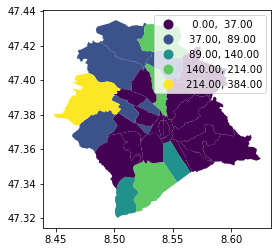

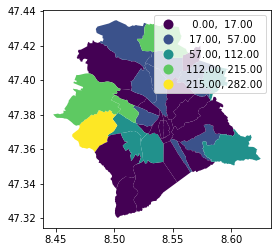

In [ ]:
# Plot by StatQuartiere
# Weitere Schemes: scheme='quantiles', scheme='fisherjenks', scheme='natural_breaks',

gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_fertigerstellt', cmap='viridis', scheme='natural_breaks', legend=True )
gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', cmap='viridis', scheme='natural_breaks', legend=True )

#gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', cmap='plasma', scheme='fisherjenks', legend=True )
#gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_fertigerstellt', cmap='cool', scheme='quantiles', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

#
#Neuere Gallerie: https://matplotlib.org/stable/gallery/index.html

<AxesSubplot:>

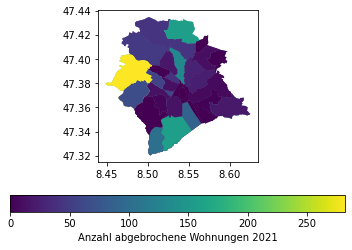

In [ ]:
fig, ax = plt.subplots(1, 1)

gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', ax=ax, legend=True, legend_kwds={'label': "Anzahl abgebrochene Wohnungen 2021",'orientation': "horizontal"})
gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_fertigerstellt', ax=ax, legend=False, legend_kwds={'label': "Anzahl fertigerstellte Wohnungen 2021",'orientation': "horizontal"})

#gdf_adm_statistische_quartiere_map_joined.plot(column='sum_Whg_abgebrochen', cmap='viridis', scheme='natural_breaks', legend=True , ax=ax, legend_kwds={'label': "Anzahl Personen",'orientation': "horizontal"})

Noch zu prüfen, folgendes schöne Beispiel: https://docs.bokeh.org/en/latest/docs/user_guide/interaction/legends.html

Konkrete Beispiele von Bookeh in Jupyter NB: https://docs.bokeh.org/en/latest/docs/user_guide/jupyter.html